# T09 - Resampling


**Nombre:** Valeria Estefanía Milke Loera

**Fecha:** 04-05-2026

**Expediente:** 739228
________

## **Ejercicios conceptuales**

### 1. Minimización de la varianza

Sea la combinación lineal:

$$
Z = \alpha X + (1 - \alpha)Y
$$

La varianza de $Z$ es:

$$
Var(Z) = \alpha^2 Var(X) + (1-\alpha)^2 Var(Y) + 2\alpha(1-\alpha)Cov(X,Y)
$$

Para encontrar el valor de $\alpha$ que minimiza la varianza, derivamos respecto a $\alpha$ e igualamos a cero:

$$
\frac{d}{d\alpha} Var(Z) = 0
$$

Al resolver esta expresión, se obtiene el valor óptimo de $\alpha$.

## 2. Bootstrap

### (a)

La probabilidad de que una observación bootstrap no sea la j-ésima es:

$$
P = 1 - \frac{1}{n}
$$

___________________

### (b)

Para la segunda observación es igual:

$$
P = 1 - \frac{1}{n}
$$

___________________

### (c)

La probabilidad de que la observación j no aparezca en toda la muestra bootstrap por ende es:

$$
\left(1 - \frac{1}{n}\right)^n
$$

_________________

### (d) n = 5

$$
P(\text{n=5}) = 1 - \left(1 - \frac{1}{5}\right)^{5} = 0.67232
$$

________________

### (e) n = 100

$$
P(\text{n=100}) = 1 - \left(1 - \frac{1}{100}\right)^{100} \approx 0.6339
$$

_______________

### (f) Para n = 10,000

$$
P(\text{n=10000}) = 1 - \left(1 - \frac{1}{10000}\right)^{10000} \approx 0.6321
$$
________________

### g) Gráfica de probabilidad 

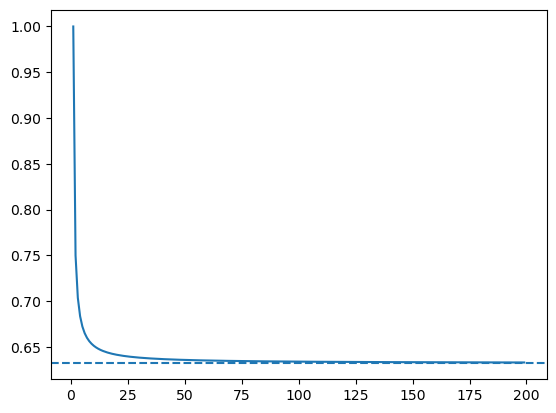

In [95]:
n_values = np.arange(1, 200)  # en vez de 100000
prob = 1 - (1 - 1/n_values)**n_values

plt.plot(n_values, prob)
plt.axhline(y=0.632, linestyle='--')
plt.show()

**Interpretación:** La gráfica muestra que la probabilidad disminuye rápidamente para valores pequeños de n y posteriormente se estabiliza alrededor de 0.632. Esto indica que, conforme aumenta el tamaño de la muestra, la probabilidad converge a un valor constante, confirmando el comportamiento esperado del bootstrap.
_____________

### h) Simulación bootstrap

In [98]:
rng = np.random.default_rng(10)

store = np.empty(10000)

for i in range(10000):
    store[i] = np.sum(rng.choice(100, size=100, replace=True) == 4) > 0

np.mean(store)

np.float64(0.6362)

**Interpretación:** El resultado obtenido mediante simulación es cercano a 0.63, lo cual coincide con el valor teórico. Esto confirma que una observación tiene aproximadamente 63.2% de probabilidad de estar en un bootstrap sample.

## 3. k-fold Cross-Validation

### (a)

El método de k-fold cross-validation consiste en dividir el dataset en k grupos (folds). De esta forma, se entrena el modelo con k-1 grupos, después se valida con el grupo restante, se repite k veces y finalmente se promedia el error  

_____________

### (b)

#### i) Comparación con Validation Set

- Más preciso  
- Mayor costo computacional  

#### ii) Comparación con LOOCV

- Menor varianza  
- Más eficiente  
- Usa menos datos en entrenamiento que LOOCV  

## 4. Estimación de la desviación estándar de la predicción

Para estimar la variabilidad de una predicción $\hat{Y}$, se puede utilizar bootstrap para:

1. Generar múltiples muestras   
2. Ajustar el modelo en cada muestra  
3. Obtener predicciones para el mismo valor de X
4. Calcular la desviación estándar  

De esta forma, el error estándar de la predicción de Y es igual a la desviación estándar de las predicciones bootstrap. 

Así, el bootstrap permite estimar la incertidumbre de la predicción sin necesidad de fórmulas analíticas complejas.

## **Ejercicios prácticos**

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from ISLP import load_data
from sklearn.linear_model import LinearRegression

## 5. Estimación del error de clasificación mediante Validation Set

In [19]:
df = pd.read_csv(r"C:\Users\valer\default.csv")
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


### a) Regresión logística con default como objetivo

In [20]:
df['default'] = df['default'].map({'Yes':1, 'No':0})

In [21]:
X = df[['income', 'balance']]
y = df['default']

In [22]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

### b) Validation set approach 

**i) Split train/validation**

In [23]:
np.random.seed(1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5
)

**ii) Ajustar con train**

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**iii) Predicciones**

In [25]:
probs = model.predict_proba(X_val)[:,1]
y_pred = (probs > 0.5).astype(int)

**iv) Error de validación**

In [26]:
error = np.mean(y_pred != y_val)
error

np.float64(0.025)

### c) Repetición del procedimiento en b)

In [27]:
errors = []
for i in range(3):
    np.random.seed(i)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.5
    )
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_val)[:,1]
    y_pred = (probs > 0.5).astype(int)
    error = np.mean(y_pred != y_val)
    errors.append(error)
errors

[np.float64(0.029), np.float64(0.025), np.float64(0.0248)]

**Interpretación:** Los errores cambian ligeramente entre cada una de las particiones, lo que indica que el método depende del split, pero los valores son similares, lo que muestra estabilidad por parte del modelo.

### d) Creación de dummy

In [28]:
df['student'] = df['student'].map({'Yes':1, 'No':0})

X = df[['income', 'balance', 'student']]
y = df['default']

In [29]:
np.random.seed(1)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
probs = model.predict_proba(X_val)[:,1]
y_pred = (probs > 0.5).astype(int)
error_student = np.mean(y_pred != y_val)
error_student

np.float64(0.0262)

**Interpretación:** El error de validación es aproximadamente 2.62%, lo que indica que el modelo clasifica correctamente mayoría de las observaciones. Al incluir la variable student, el error se mantiene bajo, lo que sugiere que el modelo tiene buen desempeño, aunque esta variable no genera una mejora tan significativa.

## 6. Estimación de errores estándar en regresión logística (GLM vs Bootstrap)

### a) Error estándar con sm.GLM()

In [31]:
X = df[['income', 'balance']]
X = sm.add_constant(X)
y = df['default']

model = sm.GLM(y, X, family=sm.families.Binomial()).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Mon, 04 May 2026   Deviance:                       1579.0
Time:                        11:13:32   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.0

### b) Bootstrap

In [33]:
def boot_fn(data, index):
    X = data[['income', 'balance']].iloc[index]
    X = sm.add_constant(X)
    y = data['default'].iloc[index]

    model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
    
    return model.params[1:] 

### c) Estimación de errores estándar

In [34]:
np.random.seed(1)

B = 1000
coefs = []

n = len(df)

for i in range(B):
    sample_index = np.random.choice(n, n, replace=True)
    coefs.append(boot_fn(df, sample_index))

coefs = np.array(coefs)

boot_se = coefs.std(axis=0)

boot_se

array([5.02857778e-06, 2.32794756e-04])

### d) Comparación entre bootstrap y GLM: 

Los errores estándar obtenidos mediante bootstrap son prácticamente iguales a los calculados con el modelo GLM. Para la variable income, ambos métodos arrojan valores cercanos (≈ 5e-06), y para balance también son similares (≈ 0.00023).

Esto indica que las estimaciones de los coeficientes son estables y confiables. El bootstrap confirma los resultados obtenidos mediante el método analítico, validando la precisión del modelo.

## 7. Estimación del error mediante Leave-One-Out Cross-Validation (LOOCV)

In [58]:
Weekly = load_data('Weekly')

In [60]:
Weekly['Direction'] = Weekly['Direction'].str.strip()
Weekly['Direction'] = Weekly['Direction'].map({'Up':1, 'Down':0})

### a) Modelo con todos los datos

In [61]:
X = Weekly[['Lag1', 'Lag2']]
y = Weekly['Direction']

In [62]:
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

### b) Modelo sin la primera obersvación 

In [63]:
X_train = X.iloc[1:]
y_train = y.iloc[1:]

In [64]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

### c) Predecir la primera obeservación

In [65]:
X_test = X.iloc[[0]]

prob = model.predict_proba(X_test)[0,1]
pred = int(prob > 0.5)

real = y.iloc[0]

prob, pred, real

(np.float64(0.5713809215379875), 1, np.int64(0))

### d) LOOCV con loop 

In [66]:
n = len(Weekly)
errors = []

for i in range(n):
    
    X_train = X.drop(i)
    y_train = y.drop(i)
    
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    X_test = X.iloc[[i]]
    y_test = y.iloc[i]
    
    prob = model.predict_proba(X_test)[0,1]
    pred = int(prob > 0.5)
    
    error = int(pred != y_test)
    errors.append(error)

### e) Error LOOCV 

In [67]:
loocv_error = np.mean(errors)
loocv_error

np.float64(0.44995408631772266)

**Interpretación:** El error LOOCV obtenido es aproximadamente 0.4995, lo que indica que el modelo clasifica incorrectamente cerca del 50% de las observaciones.

Esto sugiere que el modelo logístico que utiliza únicamente Lag1 y Lag2 tiene un desempeño similar al azar, es decir, no logra predecir adecuadamente la dirección del mercado.

En conclusión, las variables utilizadas no contienen suficiente información para explicar el comportamiento de la variable respuesta, por lo que el modelo no es adecuado para predecir correctamente. 

## 8. Evaluación de modelos polinomiales mediante LOOCV en datos simulados

### a) Generar datos

In [68]:
rng = np.random.default_rng(1)

x = rng.normal(size=100)
y = x - 2*x**2 + rng.normal(size=100)

df_sim = pd.DataFrame({'x': x, 'y': y})

### b) Scatterplot

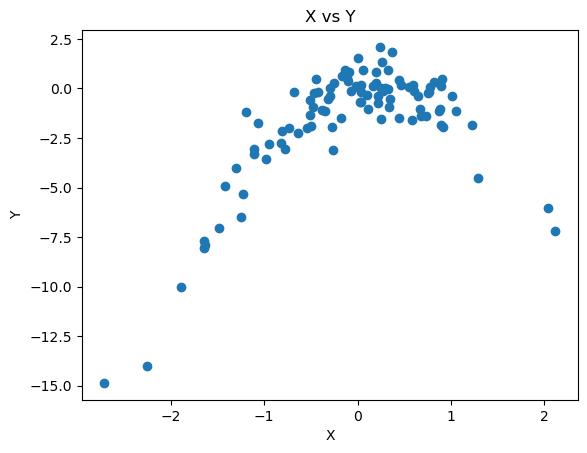

In [69]:
plt.scatter(x, y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('X vs Y')
plt.show()

### c) LOOCV para 4 modelos

In [72]:
np.random.seed(1)

n = len(df_sim)

errors = {1:[], 2:[], 3:[], 4:[]}

for i in range(n):
    
    # Train sin i
    train = df_sim.drop(i)
    test = df_sim.iloc[[i]]
    
    X_train = train['x'].values
    y_train = train['y'].values
    
    X_test = test['x'].values
    y_test = test['y'].values
    
    # Modelos
    for d in range(1,5):
        
        X_train_poly = np.column_stack([X_train**j for j in range(1,d+1)])
        X_test_poly = np.column_stack([X_test**j for j in range(1,d+1)])
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        
        pred = model.predict(X_test_poly)
        
        error = (y_test - pred)**2
        errors[d].append(error[0])

loocv_errors = {d: np.mean(errors[d]) for d in errors}
loocv_errors

{1: np.float64(6.633029839181983),
 2: np.float64(1.1229368563419682),
 3: np.float64(1.3017965489358867),
 4: np.float64(1.3323942694179325)}

### d) Repetir con otra seed 

In [74]:
rng = np.random.default_rng(2)

x = rng.normal(size=100)
y = x - 2*x**2 + rng.normal(size=100)

df_sim = pd.DataFrame({'x': x, 'y': y})

In [75]:
np.random.seed(1)

n = len(df_sim)

errors = {1:[], 2:[], 3:[], 4:[]}

for i in range(n):
    
    # Train sin i
    train = df_sim.drop(i)
    test = df_sim.iloc[[i]]
    
    X_train = train['x'].values
    y_train = train['y'].values
    
    X_test = test['x'].values
    y_test = test['y'].values
    
    # Modelos
    for d in range(1,5):
        
        X_train_poly = np.column_stack([X_train**j for j in range(1,d+1)])
        X_test_poly = np.column_stack([X_test**j for j in range(1,d+1)])
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        
        pred = model.predict(X_test_poly)
        
        error = (y_test - pred)**2
        errors[d].append(error[0])

loocv_errors = {d: np.mean(errors[d]) for d in errors}
loocv_errors

{1: np.float64(7.560603694358579),
 2: np.float64(0.984037174458258),
 3: np.float64(0.9682355765918601),
 4: np.float64(0.9659585554875685)}

**Interpretación:** Los resultados obtenidos con la nueva semilla no son exactamente iguales a los del inciso (c), pero mantienen una tendencia similar. En ambos casos, el modelo cuadrático presenta uno de los errores más bajos, lo cual es consistente con la forma real en la que se generaron los datos.

Las diferencias en los valores de error se deben a que los datos fueron generados de manera aleatoria, por lo que al cambiar la semilla se obtiene una muestra distinta. Sin embargo, la relación subyacente entre las variables se mantiene, lo que explica por qué el mejor modelo sigue siendo similar en ambos casos.

### e) Error LOOCV

El modelo con el menor error LOOCV es el de grado 2. Esto era esperado, ya que los datos fueron generados a partir de una relación cuadrática.

Por lo tanto, el modelo cuadrático captura correctamente la forma de los datos, mientras que modelos más simples no son suficientes y modelos más complejos no aportan mejoras significativas.

### f) Significancia estadística 

In [76]:
for d in range(1,5):
    X_poly = np.column_stack([x**j for j in range(1,d+1)])
    X_poly = sm.add_constant(X_poly)
    
    model = sm.OLS(y, X_poly).fit()
    
    print(f"\nModelo grado {d}")
    print(model.summary())


Modelo grado 1
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     18.15
Date:                Mon, 04 May 2026   Prob (F-statistic):           4.68e-05
Time:                        11:42:10   Log-Likelihood:                -238.27
No. Observations:                 100   AIC:                             480.5
Df Residuals:                      98   BIC:                             485.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8158      0.265    

**Interpretación:** Al analizar los resultados de los modelos, se observa que en todos los casos los coeficientes asociados a X y X^2 son altamente significativos. Sin embargo, en los modelos de grado 3 y 4, los coeficientes no son estadísticamente significativos (p-values mayores a 0.05). Esto indica que los términos de mayor grado no aportan información relevante al modelo.

Estos resultados coinciden con los obtenidos mediante LOOCV, donde el modelo de grado 2 presentó el menor error. Por lo tanto, tanto la validación cruzada como la significancia estadística sugieren que el modelo cuadrático es el más adecuado.

## 9. Estimación de parámetros poblacionales y errores estándar mediante Bootstrap

In [79]:
df = pd.read_excel(r"C:\Users\valer\bhd.xlsx")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### a) Media poblacional estimada

In [80]:
mu_hat = np.mean(df['MEDV'])
mu_hat

np.float64(23.750442477876106)

### b) Error estándar 

In [81]:
se_hat = np.std(df['MEDV'], ddof=1) / np.sqrt(len(df))
se_hat

np.float64(0.3915901080014807)

### c) Bootstrap para error estándar 

In [82]:
np.random.seed(1)

B = 1000
means = []
n = len(df)

for i in range(B):
    sample = df['MEDV'].sample(n, replace=True)
    means.append(sample.mean())

boot_se = np.std(means)
boot_se

np.float64(0.4156779347407137)

**Interpretación:** El error estándar obtenido mediante bootstrap (0.4157) es ligeramente mayor al calculado con la fórmula analítica (0.3916), aunque ambos valores son muy cercanos.

Esto indica que la estimación de la media es estable. La pequeña diferencia se debe a la variabilidad inherente del método bootstrap, el cual utiliza remuestreo aleatorio.

### d) Intervalo de confianza 

In [83]:
lower = mu_hat - 2*boot_se
upper = mu_hat + 2*boot_se

(lower, upper)

(np.float64(22.91908660839468), np.float64(24.581798347357534))

**Comparación con b) y c):** El intervalo de confianza fue construido utilizando el error estándar obtenido mediante bootstrap, el cual es ligeramente mayor que el calculado con la fórmula analítica. Esto hace que el intervalo sea un poco más amplio, reflejando una mayor variabilidad en la estimación.

Sin embargo, dado que ambos errores estándar son similares, el intervalo de confianza es consistente con la estimación obtenida en (b) y (c), confirmando que la media poblacional se encuentra dentro de un rango razonable.

### e) Mediana

In [86]:
df = df.dropna(subset=['MEDV'])

In [87]:
mu_med = np.median(df['MEDV'])
mu_med

np.float64(21.95)

### f) Boostrap para la mediana

In [88]:
medians = []

for i in range(B):
    sample = df['MEDV'].sample(n, replace=True)
    medians.append(np.median(sample))

boot_se_med = np.std(medians)
boot_se_med

np.float64(0.28467451150392814)

**Interpretación:** El error estándar de la mediana estimado mediante bootstrap es aproximadamente 0.2847, lo que indica que la mediana es una medida relativamente estable. Dado que no existe una fórmula analítica sencilla para calcular el error estándar de la mediana, el uso del bootstrap resulta adecuado para estimar su variabilidad. 

### g) Percentil 10

In [89]:
mu_10 = np.percentile(df['MEDV'], 10)
mu_10

np.float64(14.5)

### h) Bootstrap para percentil 10

In [90]:
p10 = []

for i in range(B):
    sample = df['MEDV'].sample(n, replace=True)
    p10.append(np.percentile(sample, 10))

boot_se_p10 = np.std(p10)
boot_se_p10

np.float64(0.389918321575173)

**Interpretación:** El error estándar del percentil 10 obtenido mediante bootstrap es aproximadamente 0.3899, lo que indica una mayor variabilidad en comparación con la mediana. Esto se debe a que los percentiles en los extremos de la distribución tienden a ser más sensibles a los cambios en los datos. Aun así, el bootstrap permite estimar de manera efectiva esta variabilidad, proporcionando una medida confiable.